STEP 1:  Install Libraries

In [1]:
!pip install transformers datasets torch scikit-learn nltk wordcloud streamlit -q

STEP 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


STEP 3: Upload Dataset

In [3]:
# Install Kaggle API client
!pip install kaggle -q

import os
import zipfile

# Create the .kaggle directory if it doesn't exist
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

# Assuming kaggle.json is uploaded to the current directory using files.upload() in cell vVCQz6YQew3V
# We need to move it to the ~/.kaggle directory for the Kaggle API to work.
kaggle_json_source_path = 'kaggle.json'
kaggle_json_destination_path = os.path.join(kaggle_dir, 'kaggle.json')

if os.path.exists(kaggle_json_source_path):
    os.rename(kaggle_json_source_path, kaggle_json_destination_path)
    os.chmod(kaggle_json_destination_path, 0o600)
    print("Kaggle API key configured.")
else:
    print("WARNING: 'kaggle.json' not found in the current directory.")
    print("Please ensure you have uploaded your Kaggle API key using 'files.upload()' in cell `vVCQz6YQew3V`.")
    print("If you have just uploaded it, please re-run this cell to configure the Kaggle API.")

# Download the dataset from Kaggle
dataset_slug = "nikhileswarkomati/suicide-watch"
print(f"Downloading dataset: {dataset_slug}")
!kaggle datasets download -d {dataset_slug}

# Unzip the downloaded dataset
zip_file_name = "suicide-watch.zip" # Kaggle usually names the zip file after the dataset slug
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Dataset '{zip_file_name}' unzipped.")
    os.remove(zip_file_name) # Clean up the zip file
    print(f"Removed '{zip_file_name}'.")
else:
    print(f"ERROR: '{zip_file_name}' not found. Dataset download might have failed or the file name is different.")

# Verify the presence of the CSV file required by subsequent cells
if os.path.exists("Suicide_Detection.csv"):
    print("Successfully downloaded and extracted 'Suicide_Detection.csv'.")
else:
    print("CRITICAL ERROR: 'Suicide_Detection.csv' is still not found. Subsequent cells may fail.")


Please ensure you have uploaded your Kaggle API key using 'files.upload()' in cell `vVCQz6YQew3V`.
If you have just uploaded it, please re-run this cell to configure the Kaggle API.
Dataset URL: https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch
License(s): CC-BY-SA-4.0
100% 60.6M/60.6M [00:00<00:00, 105MB/s]

Dataset 'suicide-watch.zip' unzipped.
Removed 'suicide-watch.zip'.
Successfully downloaded and extracted 'Suicide_Detection.csv'.


STEP 4: Read Dataset

In [4]:
import pandas as pd
# Load dataset using the absolute path
df = pd.read_csv("/content/Suicide_Detection.csv")

# Show first rows
print(df.head(6000))

      Unnamed: 0                                               text  \
0              2  Ex Wife Threatening SuicideRecently I left my ...   
1              3  Am I weird I don't get affected by compliments...   
2              4  Finally 2020 is almost over... So I can never ...   
3              8          i need helpjust help me im crying so hard   
4              9  I’m so lostHello, my name is Adam (16) and I’v...   
...          ...                                                ...   
5995        8975  Ugh, I have a test at 9 in the god damn mornin...   
5996        8976  The day is fast approaching where I'll take my...   
5997        8977  my mom saw the noose i had in the background o...   
5998        8978  god it’s hard to get betteri’ve been in PHP fo...   
5999        8979  Former space security chief of Israel says ali...   

            class  
0         suicide  
1     non-suicide  
2     non-suicide  
3         suicide  
4         suicide  
...           ...  
5995  n

STEP 5: Check Dataset Columns

In [5]:
print(df.columns)

Index(['Unnamed: 0', 'text', 'class'], dtype='object')


In [6]:
df = df.rename(columns={
    'text':'text',
    'class':'label'
})

STEP 6:  Basic Dataset Information

In [7]:
print(df.shape)
print(df.isnull().sum())
print(df['label'].value_counts())

(232074, 3)
Unnamed: 0    0
text          0
label         0
dtype: int64
label
suicide        116037
non-suicide    116037
Name: count, dtype: int64


STEP 7: Remove Missing Values

In [8]:
df = df.dropna()

STEP 8:  Convert Labels into Numbers

In [9]:
df['label'] = df['label'].map({
    'suicide':1,
    'non-suicide':0
})


In [10]:
print(df['label'].value_counts())

label
1    116037
0    116037
Name: count, dtype: int64


STEP 9:  Text Cleaning

In [11]:
stop_words = set(stopwords.words('english'))


def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags symbol only
    text = re.sub(r'#', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['clean_text'] = df['text'].apply(clean_text)

STEP 10:  Show Cleaned Text

In [12]:
print(df[['text', 'clean_text']].head())

                                                text  \
0  Ex Wife Threatening SuicideRecently I left my ...   
1  Am I weird I don't get affected by compliments...   
2  Finally 2020 is almost over... So I can never ...   
3          i need helpjust help me im crying so hard   
4  I’m so lostHello, my name is Adam (16) and I’v...   

                                          clean_text  
0  ex wife threatening suiciderecently i left my ...  
1  am i weird i dont get affected by compliments ...  
2  finally is almost over so i can never hear has...  
3          i need helpjust help me im crying so hard  
4  i’m so losthello my name is adam and i’ve been...  


STEP 11: Exploratory Data Analysis

label
1    116037
0    116037
Name: count, dtype: int64


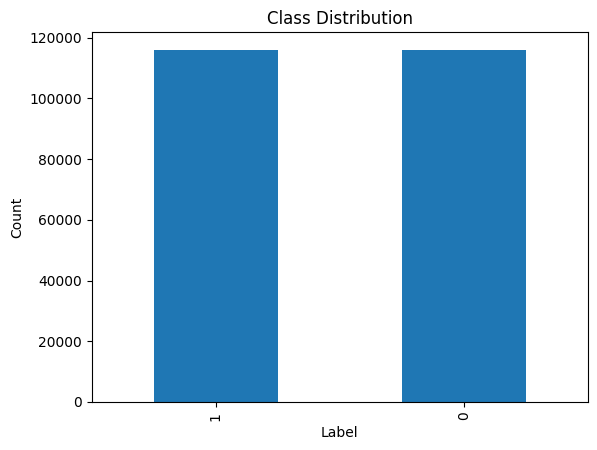

In [13]:
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

print(label_counts)

label_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

STEP 12: Word Cloud for Suicidal Posts

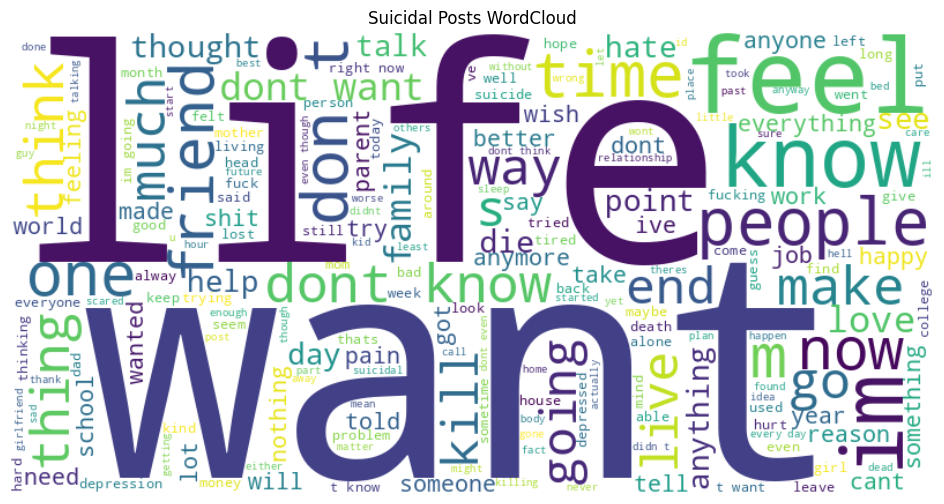

In [14]:
from wordcloud import WordCloud

# Get only suicidal text
suicidal_df = df[df['label'] == 1]

# Convert into one big string
suicidal_text = ' '.join(suicidal_df['clean_text'].astype(str))

# Generate wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(suicidal_text)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Suicidal Posts WordCloud')
plt.show()

STEP 13:  Train Test Split

### Reducing Dataset Size to Avoid Memory Issues

The previous error indicates that the dataset is too large for the available RAM during tokenization. To proceed without crashing, we will sample a smaller subset of the data. We'll aim for `10,000` entries, ensuring that the class distribution (suicide/non-suicide) is maintained through stratification.

In [15]:
# Sample a smaller portion of the dataset to reduce memory usage
# Using stratify to maintain class balance
sampled_df = df.groupby('label').apply(lambda x: x.sample(n=5000, random_state=42)).reset_index(drop=True)

print(f"Original dataset size: {len(df)}")
print(f"Sampled dataset size: {len(sampled_df)}")
print("Sampled dataset label distribution:")
print(sampled_df['label'].value_counts())


Original dataset size: 232074
Sampled dataset size: 10000
Sampled dataset label distribution:
label
0    5000
1    5000
Name: count, dtype: int64


/tmp/ipykernel_11316/3909455777.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('label').apply(lambda x: x.sample(n=5000, random_state=42)).reset_index(drop=True)


In [16]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    sampled_df['clean_text'].tolist(),
    sampled_df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=sampled_df['label']
)

STEP 14: Load BERT Tokenizer

In [17]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

STEP 15:  Tokenization

In [18]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)


test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

STEP 16: Create HuggingFace Dataset

In [19]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels
})


test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels
})

STEP 17: Load BERT Model

In [20]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


STEP 18:  Define Metrics

In [21]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

STEP 19: Training Arguments

In [22]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    do_eval=True,
    save_steps=500,
    fp16=torch.cuda.is_available()
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


STEP 20: Trainer

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

STEP 21:  Train Model

In [24]:
trainer.train()

Step,Training Loss
50,0.609132
100,0.412521
150,0.341285
200,0.219360
250,0.188347
300,0.178193
350,0.195920
400,0.168454
450,0.197347
500,0.119563


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.0732782147794962, metrics={'train_runtime': 692.8575, 'train_samples_per_second': 57.732, 'train_steps_per_second': 7.216, 'total_flos': 2631110553600000.0, 'train_loss': 0.0732782147794962, 'epoch': 5.0})

STEP 22: Evaluate Model

In [25]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.23857060074806213, 'eval_accuracy': 0.966, 'eval_precision': 0.963220675944334, 'eval_recall': 0.969, 'eval_f1': 0.9661016949152542, 'eval_runtime': 4.7132, 'eval_samples_per_second': 424.338, 'eval_steps_per_second': 53.042, 'epoch': 5.0}


STEP 23:  Detailed Classification Report

In [26]:
predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1000
           1       0.96      0.97      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



STEP 24: Save Model

In [27]:
model.save_pretrained('mental_health_model')
tokenizer.save_pretrained('mental_health_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('mental_health_model/tokenizer_config.json',
 'mental_health_model/tokenizer.json')

STEP 25: Load Saved Model

In [28]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model='mental_health_model',
    tokenizer='mental_health_model'
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

STEP 26: Prediction Function

In [29]:
def predict_risk(text):
    cleaned = clean_text(text)

    result = classifier(cleaned)[0]

    label = result['label']
    score = result['score']

    if label == 'LABEL_1':
        prediction = 'Suicidal'
    else:
        prediction = 'Non-Suicidal'

    urgency_score = round(score * 100, 2)

    return {
        'prediction': prediction,
        'urgency_score': urgency_score
    }

STEP 27: Test Custom Text

In [30]:
sample_text = "I feel hopeless and I do not want to live anymore"

result = predict_risk(sample_text)

print(result)

{'prediction': 'Suicidal', 'urgency_score': 99.87}


STEP 28: Sentence Highlighting

In [31]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize


def highlight_sentences(text):
    sentences = sent_tokenize(text)

    dangerous_sentences = []

    for sentence in sentences:
        result = predict_risk(sentence)

        if result['prediction'] == 'Suicidal':
            dangerous_sentences.append({
                'sentence': sentence,
                'urgency': result['urgency_score']
            })

    return dangerous_sentences

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


STEP 29: Test Sentence Highlighting

In [32]:
text = "I am tired of life. Nobody understands me. I want to disappear forever."

highlighted = highlight_sentences(text)

print(highlighted)

[{'sentence': 'I am tired of life.', 'urgency': 99.34}, {'sentence': 'Nobody understands me.', 'urgency': 99.96}, {'sentence': 'I want to disappear forever.', 'urgency': 99.61}]
